# Customer Churn Prediction

# Exploratory Data Analysis

In [1]:
# import
import pandas as pd
df = pd.read_csv('datasets/Data_Science_Challenge.csv')

## Data Types

In [2]:
# data types of columns
def df_datatypes(df):
    df_desc = pd.DataFrame(df.dtypes.value_counts().reset_index())
    df_desc.columns = ['Data Type', 'Count']
    return df_desc.sort_values('Count', ascending=False)

df['area code'] = df['area code'].astype('category')

df_datatypes(df)

,Data Type,Count
0,float64,8
1,int64,7
2,str,4
3,category,1
4,bool,1


## Categorical

In [3]:
# categorical - describe
import numpy as np
def df_describe_categorical(df):
    return df.select_dtypes(exclude=np.number).describe()

df_describe_categorical(df)

,state,area code,phone number,international plan,voice mail plan,churn
count,3333,3333,3333,3333,3333,3333
unique,51,3,3333,2,2,2
top,WV,415,382-4657,no,no,False
freq,106,1655,1,3010,2411,2850


## Numerical

In [4]:
# numerical - describe
def df_describe_numerical(df):
    return df.select_dtypes(include=np.number).describe()

df_describe_numerical(df)

,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


<Axes: >

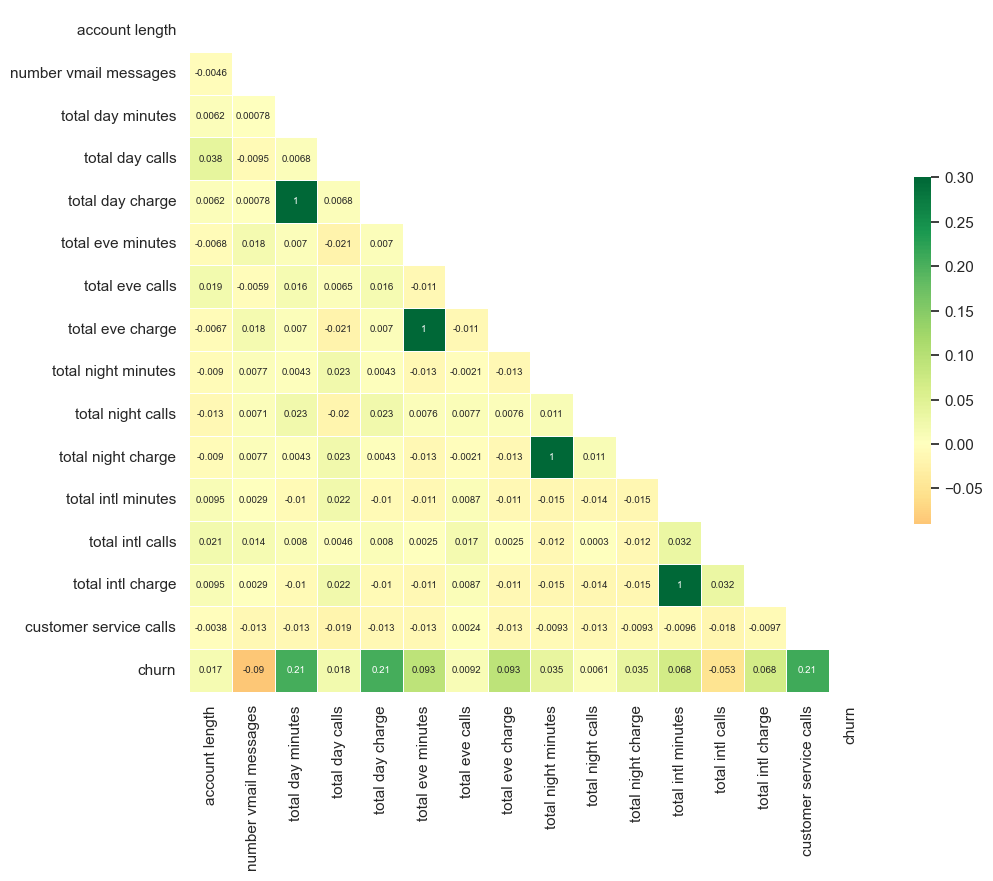

In [5]:
# numerical - correlogram
from matplotlib import pyplot as plt
import seaborn as sns
def graph_correlogram(df):
    sns.set_theme(style="white") 
    # Compute the correlation matrix
    corr = df.corr(numeric_only=True)
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))
    # Draw the heatmap with the mask and correct aspect ratio
    graph = sns.heatmap(corr, mask=mask, cmap='RdYlGn', vmax=.3, center=0, square=True, annot=True, linewidths=.5, cbar_kws={"shrink": .5, }, annot_kws={'size': 7})
    return graph

graph_correlogram(df)

In [6]:
# correlation matrix with p-values
import pingouin as pg
def df_correlation_matrix(df):
    numerical = df.select_dtypes(include=['int64', 'float']).columns.tolist()
    print(f'Pearson Correlation Matrix with P-Values')
    print(f'[Coef in Btm Tri / p-Values in Up Tri]')
    print(f'*** for <0.001, ** for <0.01, * for <0.05')
    print(f'-----------------------------------------')
    return df[numerical].rcorr(method='pearson').round(3)

df_correlation_matrix(df)

Pearson Correlation Matrix with P-Values
[Coef in Btm Tri / p-Values in Up Tri]
*** for <0.001, ** for <0.01, * for <0.05
-----------------------------------------


,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
account length,-,,,*,,,,,,,,,,,
number vmail messages,-0.005,-,,,,,,,,,,,,,
total day minutes,0.006,0.001,-,,***,,,,,,,,,,
total day calls,0.038,-0.01,0.007,-,,,,,,,,,,,
total day charge,0.006,0.001,1.0,0.007,-,,,,,,,,,,
total eve minutes,-0.007,0.018,0.007,-0.021,0.007,-,,***,,,,,,,
total eve calls,0.019,-0.006,0.016,0.006,0.016,-0.011,-,,,,,,,,
total eve charge,-0.007,0.018,0.007,-0.021,0.007,1.0,-0.011,-,,,,,,,
total night minutes,-0.009,0.008,0.004,0.023,0.004,-0.013,-0.002,-0.013,-,,***,,,,
total night calls,-0.013,0.007,0.023,-0.02,0.023,0.008,0.008,0.008,0.011,-,,,,,


## Missing Data

In [7]:
# dataframe missing
def df_missing_info(df):
    pd.set_option('display.max_columns', df.shape[1])
    pd.set_option('display.max_rows', df.shape[1])
    descriptive_df = pd.DataFrame()
    descriptive_df['column'] = df.columns
    descriptive_df['data type'] = df.dtypes.tolist()
    descriptive_df['# missing'] = [df[col].isnull().sum() for col in df]
    descriptive_df['% missing'] = np.round(descriptive_df['# missing'] / df.shape[0], 4)
    return descriptive_df

df_missing_info(df)

,column,data type,# missing,% missing
0,state,str,0,0.0
1,account length,int64,0,0.0
2,area code,category,0,0.0
3,phone number,str,0,0.0
4,international plan,str,0,0.0
5,voice mail plan,str,0,0.0
6,number vmail messages,int64,0,0.0
7,total day minutes,float64,0,0.0
8,total day calls,int64,0,0.0
9,total day charge,float64,0,0.0


## Anova (Churn vs df)

In [8]:
# anova df
import warnings
def get_anova_df(target, df):
    # filter warnings
    warnings.simplefilter(action='ignore', category=FutureWarning)
    numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
    anova_df = pd.DataFrame()
    for num in numerical_columns:
        new_row = df.anova(dv=num, between=target, detailed=False)
        new_row['Target'] = num
        new_row = new_row.rename(columns={'Target':'Feature', 'Source':'Target'})
        anova_df = pd.concat([anova_df, new_row], axis='rows')
    anova_df = anova_df[['Target', 'Feature','F', 'p_unc', 'np2']]
    return anova_df

anova_df = get_anova_df('churn', df)

### Statistically Significant

In [9]:
anova_df.loc[
    anova_df['p_unc'] <= 0.05
]

,Target,Feature,F,p_unc,np2
0,churn,number vmail messages,27.035912,2.117522e-07,0.008051
0,churn,total day minutes,146.350785,5.300278e-33,0.042087
0,churn,total day charge,146.350657,5.300606e-33,0.042087
0,churn,total eve minutes,28.932577,8.011339e-08,0.008611
0,churn,total eve charge,28.926444,8.036524e-08,0.008609
0,churn,total night minutes,4.201496,4.046648e-02,0.001260
0,churn,total night charge,4.202136,4.045122e-02,0.001260
0,churn,total intl minutes,15.583468,8.057311e-05,0.004657
0,churn,total intl calls,9.327945,2.274701e-03,0.002793
0,churn,total intl charge,15.592581,8.018754e-05,0.004659


### Statistically Insignificant

In [10]:
anova_df.loc[
    anova_df['p_unc'] > 0.05
]

,Target,Feature,F,p_unc,np2
0,churn,account length,0.911598,0.339760,0.000274
0,churn,total day calls,1.135412,0.286701,0.000341
0,churn,total eve calls,0.283994,0.594131,0.000085
0,churn,total night calls,0.125631,0.723028,0.000038


## Histograms of Numerical

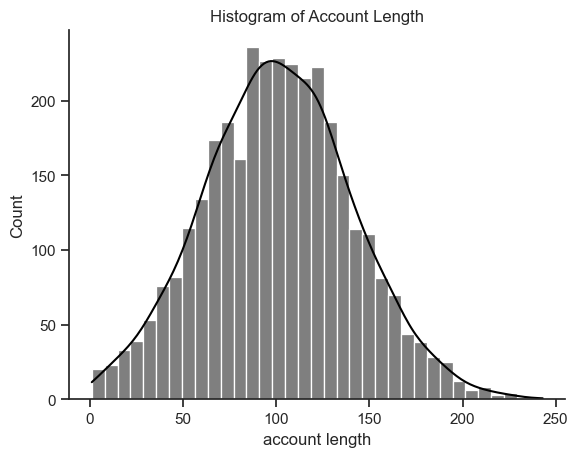

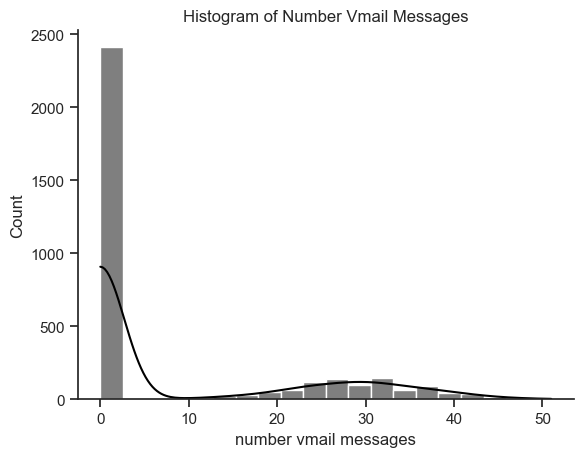

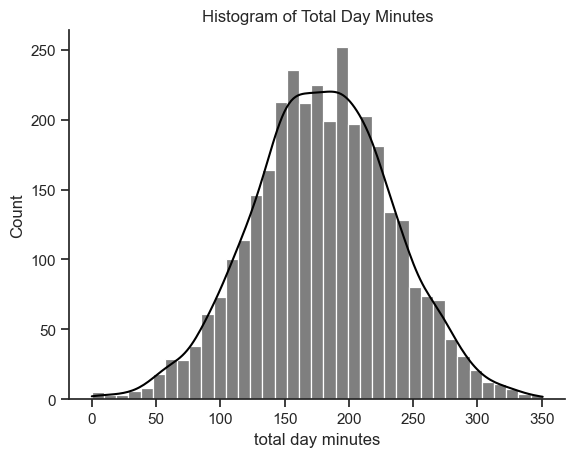

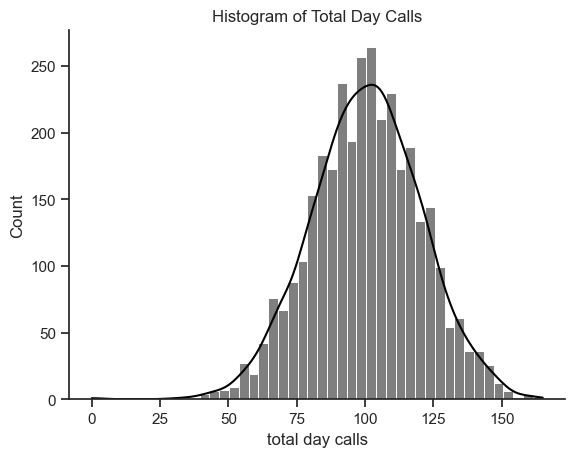

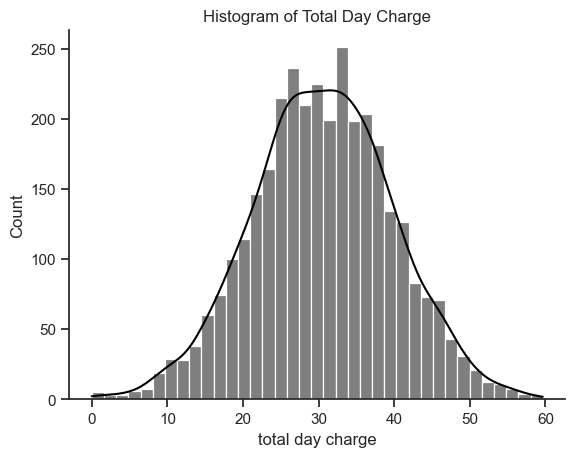

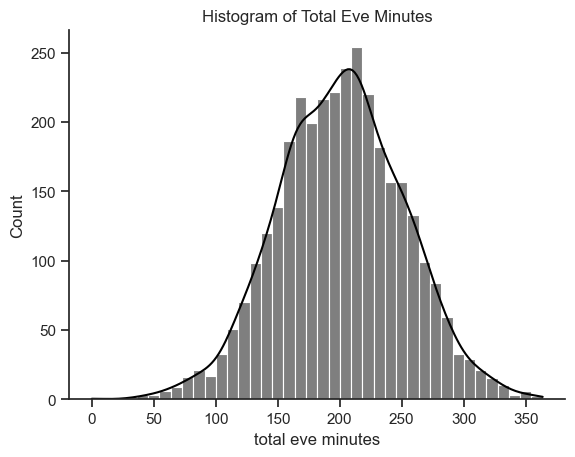

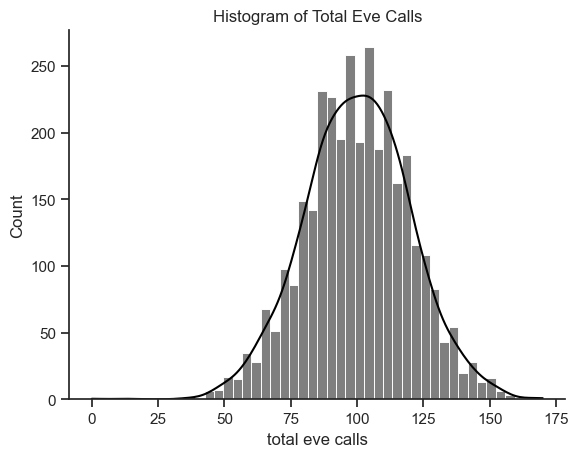

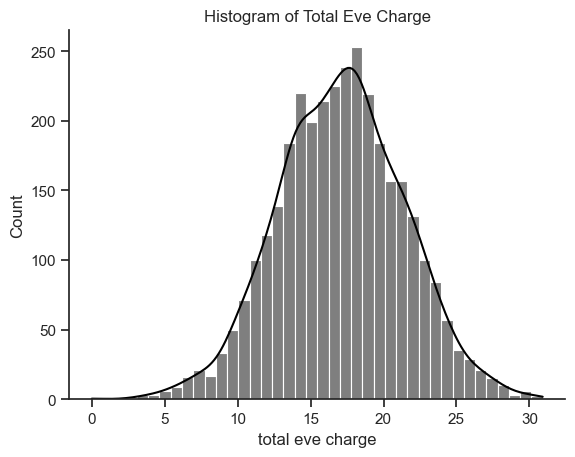

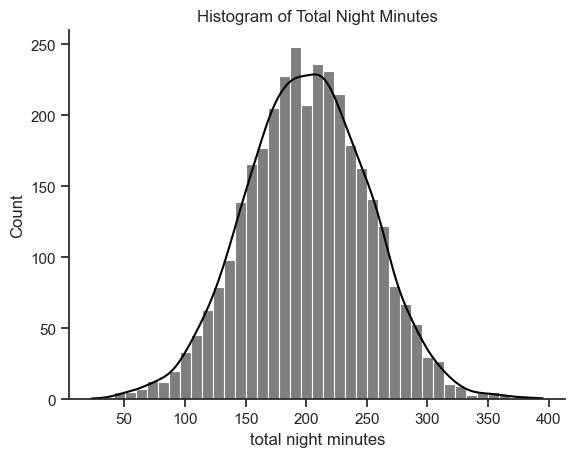

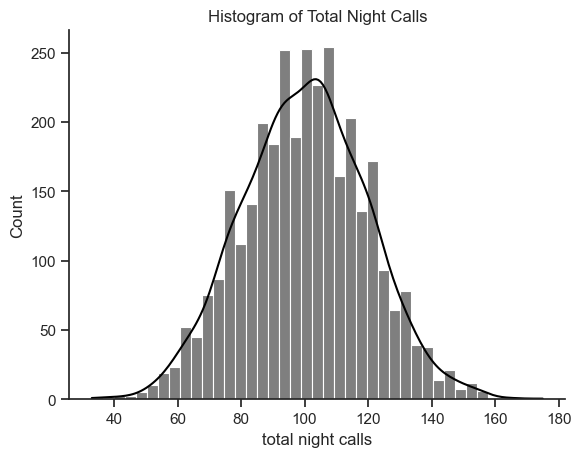

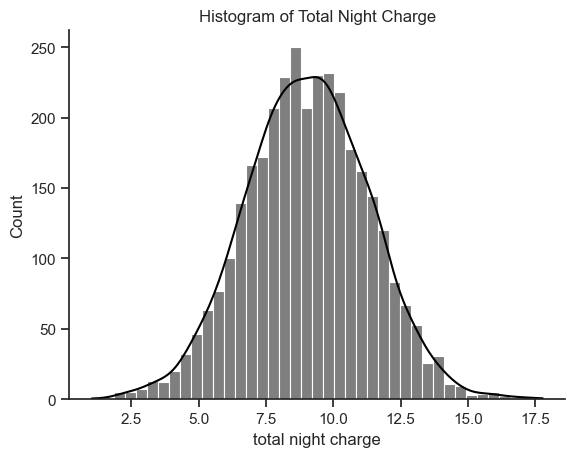

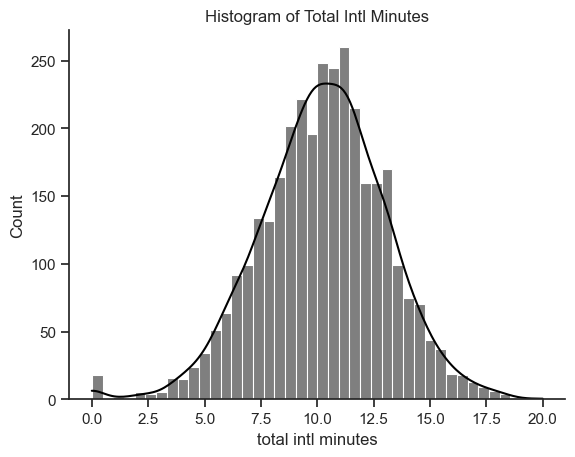

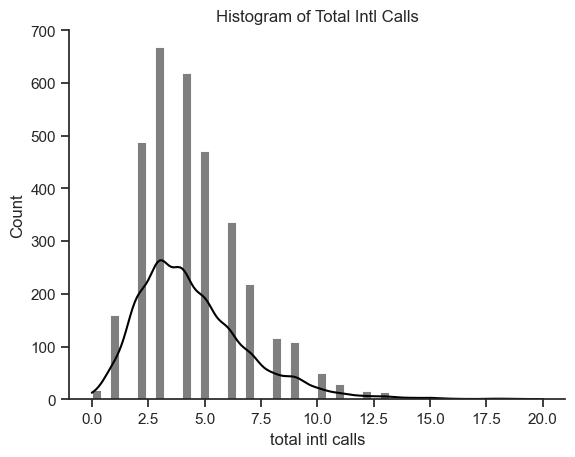

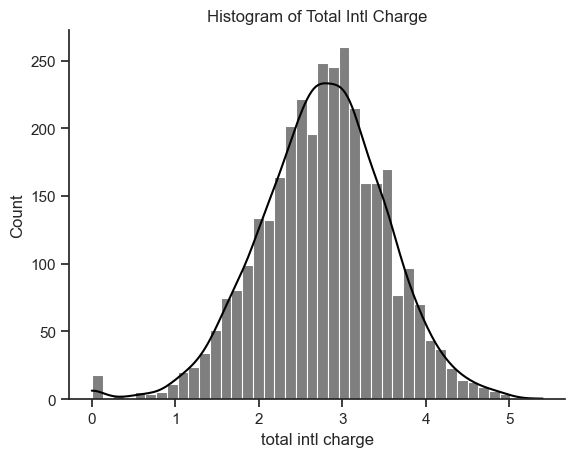

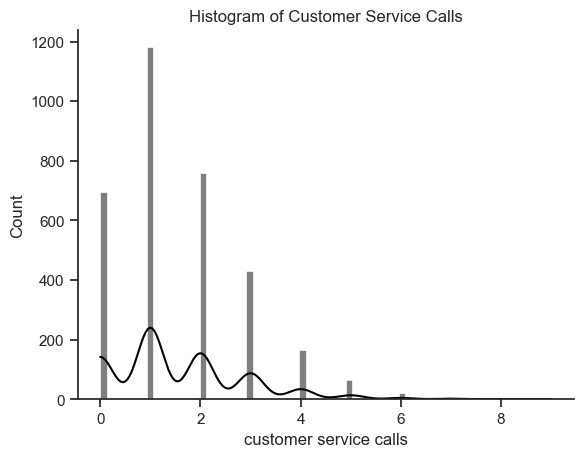

In [11]:
# graph of all numeric data types
def graph_numeric_histograms(df):
    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    sns.set_theme(style="ticks", rc=custom_params)
    numeric_columns = df.select_dtypes(include=np.number)
    for col in numeric_columns:
        sns.histplot(df[col], kde=True, color='black')
        plt.title(f'Histogram of {col.title()}')
        plt.show()
        
graph_numeric_histograms(df)

# Mutual Information Statistic

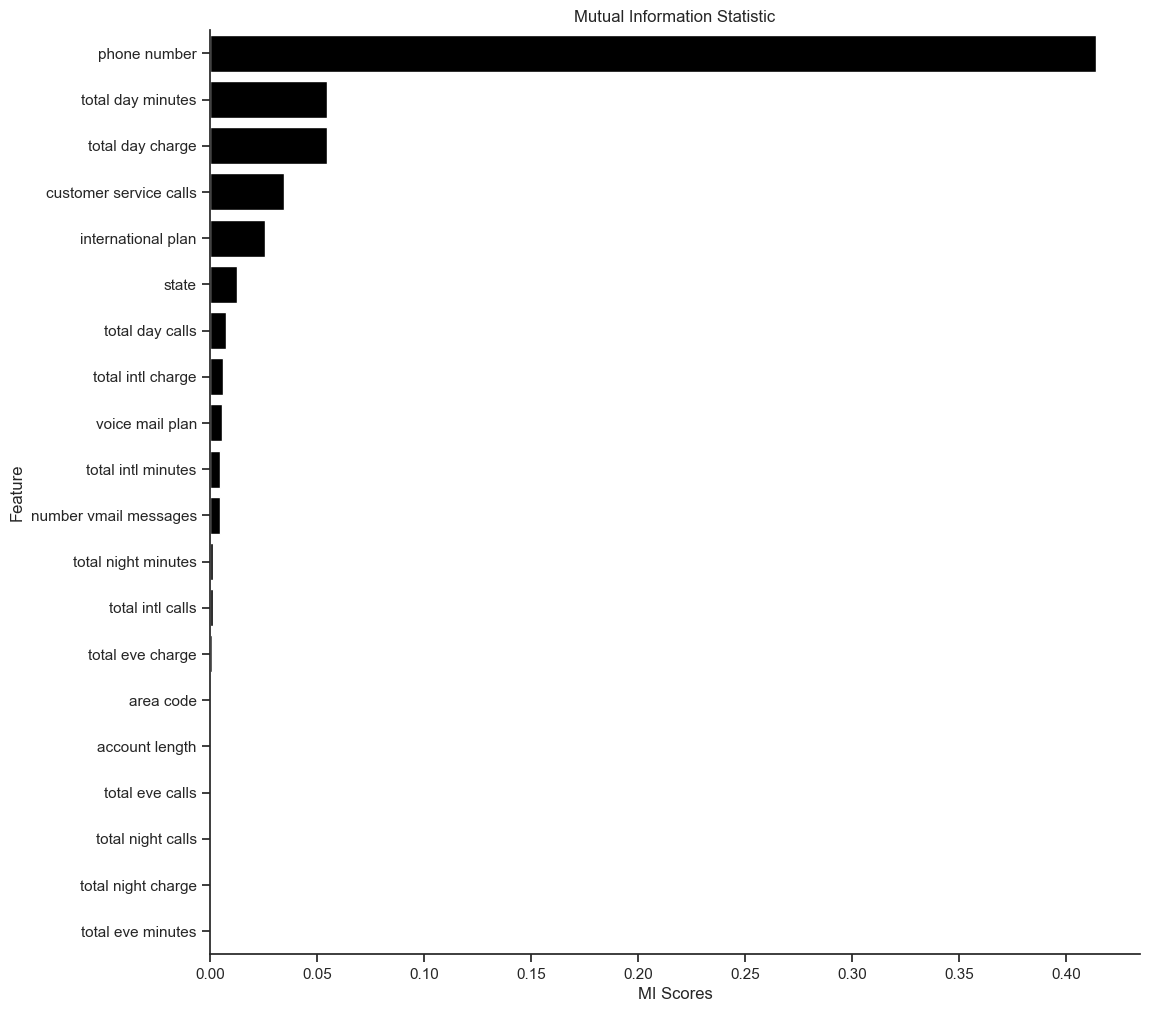

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif

# separate x & y data
X = df.drop(['churn'], axis=1)
y = LabelEncoder().fit_transform(df['churn'])

# numeric pipeline
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('min-max', MinMaxScaler(feature_range=(1, 2))))
numeric_pipeline_steps.append(('box-cox', PowerTransformer(method='box-cox')))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# categorical pipeline
categorical_pipeline_steps = []
categorical_pipeline_steps.append(('oe', OrdinalEncoder(dtype=np.int64)))
categorical_pipeline = Pipeline(steps=categorical_pipeline_steps)

# create transformer
cat_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
num_columns = X.select_dtypes(include=[np.number]).columns.tolist()

transformer_steps = []
transformer_steps.append(('cat', categorical_pipeline, cat_columns))
transformer_steps.append(('num', numeric_pipeline, num_columns))
preprocessing_transformer=ColumnTransformer(transformers=transformer_steps)

# preprocessing transformer
preprocessing_transformer

# preprocess X data
pp_X = preprocessing_transformer.fit_transform(X)

# create dataframe for results
raw_features = preprocessing_transformer.get_feature_names_out()
pp_X_columns = pd.Series(raw_features).str.replace(r'^(num__|cat__)', '', regex=True)
pp_X_df = pd.DataFrame(pp_X, columns=pp_X_columns)

# get discrete feature indices
discrete_features_for_mi = [ind for ind, li in enumerate(pp_X_df.columns) if li in cat_columns]

# run mutual_info_classif
mi_scores = mutual_info_classif(pp_X_df, y, discrete_features=discrete_features_for_mi, random_state=2022)

# make df of mi
mi_scores_df = pd.DataFrame({'Feature': pp_X_df.columns, 'MI Scores': mi_scores}).sort_values('MI Scores', ascending=False)

# bar plot
plt.figure(figsize=(12, 12))
sns.barplot(y='Feature', x='MI Scores', data=mi_scores_df, color='black')
plt.title('Mutual Information Statistic')
plt.show()

In [81]:
# dataframe of mi scores
mi_scores_df.round(3)

,Feature,MI Scores
2,area code,0.414
7,total day minutes,0.055
9,total day charge,0.055
19,customer service calls,0.034
3,phone number,0.026
0,state,0.012
8,total day calls,0.008
18,total intl charge,0.006
4,international plan,0.006
16,total intl minutes,0.005


# Model Preparation

In [82]:
# split into train, test data
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('churn', axis='columns'),
    df['churn'],
    stratify=df['churn'],
    test_size=0.30,
    random_state=2022
    )

In [83]:
# Separate Columns by type
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category', 'str']).columns

In [84]:
# seperate high and low cardinality features
n_unique_categories = X_train[categorical_features].nunique()
high_cardinality_features = n_unique_categories[n_unique_categories > 50].index
low_cardinality_features = n_unique_categories[n_unique_categories <= 50].index

In [85]:
df_describe_categorical(X_train[high_cardinality_features])

,state,phone number
count,2333,2333
unique,51,2333
top,WV,416-8697
freq,72,1


In [86]:
df_describe_categorical(X_train[low_cardinality_features])

,area code,international plan,voice mail plan
count,2333,2333,2333
unique,3,2,2
top,415,no,no
freq,1157,2121,1721


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, TargetEncoder
from sklearn.compose import make_column_selector
from sklearn import set_config
from sklearn.impute import SimpleImputer

# Numeric Feature Pipeline
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('scaler', StandardScaler()))
numeric_pipeline_steps.append(('poly', PolynomialFeatures(degree=2)))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# Low Categorical Feature Pipeline
low_categorical_pipeline_steps = []
low_categorical_pipeline_steps.append(('imputer', SimpleImputer(strategy='constant', fill_value='missing', add_indicator=True)))
low_categorical_pipeline_steps.append(('onehot', OneHotEncoder(handle_unknown='ignore')))
low_categorical_pipeline = Pipeline(steps=low_categorical_pipeline_steps)

# High Categorical Feature Pipeline
high_categorical_pipeline_steps = []
high_categorical_pipeline_steps.append(('imputer', SimpleImputer(strategy='constant', fill_value='missing', add_indicator=True)))
high_categorical_pipeline_steps.append(('target_encoder', TargetEncoder(target_type='binary')))
high_categorical_pipeline = Pipeline(steps=high_categorical_pipeline_steps)

# Preprocessing Transformer
transformer_steps = []
transformer_steps.append(('low_cat', low_categorical_pipeline, low_cardinality_features))
transformer_steps.append(('high_cat', high_categorical_pipeline, high_cardinality_features))
transformer_steps.append(('num', numeric_pipeline, make_column_selector(dtype_include=np.number)))
preprocessing_transformer=ColumnTransformer(transformers=transformer_steps)

# Display Transformer
set_config(display='diagram')
preprocessing_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('low_cat', ...), ('high_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [88]:
# Models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = []
models.append(('DC', DummyClassifier(strategy='most_frequent')))
models.append(('AB-C', AdaBoostClassifier(n_estimators=1000, random_state=2022)))
models.append(('LR', LogisticRegression(solver='saga', penalty='elasticnet', class_weight='balanced', l1_ratio=0.5, max_iter=100_000, random_state=2022)))
models.append(('RF', RandomForestClassifier(n_estimators=1000, class_weight='balanced', random_state=2022)))
models.append(('DTC', DecisionTreeClassifier()))
models.append(('KNN', KNeighborsClassifier(weights='distance')))
models.append(('SVC-L', SVC(kernel='linear', class_weight='balanced')))
models.append(('SVC-P', SVC(kernel='poly', class_weight='balanced')))
models.append(('SVC-R', SVC(kernel='rbf', class_weight='balanced')))
models.append(('SVC-S', SVC(kernel='sigmoid', class_weight='balanced')))
models.append(('XGB-C', XGBClassifier(eval_metric='logloss', seed=2022)))

# Spot Check Algorithms

In [89]:
# results dataframe
results = pd.DataFrame()

# scoring used
scoring = 'accuracy'

# CV
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=2022)

for name, model in models:
    # Pipeline
    model_pipeline_steps = []
    model_pipeline_steps.append(('transformer', preprocessing_transformer))
    model_pipeline_steps.append(('model', model))
    pipeline = Pipeline(steps=model_pipeline_steps)
    # CV results
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    temp_df = pd.DataFrame({name: pd.Series(abs(cv_results))})
    results = pd.concat([results, temp_df], axis='columns')
    # Mean +/- std
    msg = f'{name}: {cv_results.mean().round(5)} \u00B1 {cv_results.std().round(5)}'
    print(msg)

DC: 0.85512 ± 0.00165
AB-C: 0.91171 ± 0.01211
LR: 0.83669 ± 0.02466
RF: 0.93827 ± 0.01699
DTC: 0.90697 ± 0.02107
KNN: 0.88599 ± 0.0135
SVC-L: 0.84999 ± 0.02943
SVC-P: 0.89583 ± 0.01429
SVC-R: 0.89284 ± 0.01285
SVC-S: 0.73424 ± 0.02627
XGB-C: 0.94899 ± 0.01206


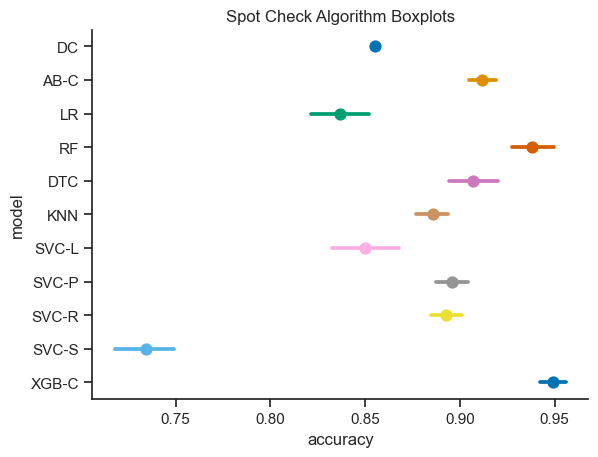

In [90]:
# Algorithm Comparison Boxplot
sns.pointplot(y='model', x=scoring,
            data=pd.melt(results, var_name='model', value_name=scoring), palette='colorblind')
plt.title('Spot Check Algorithm Boxplots')
plt.show()

In [91]:
# print df
results


,DC,AB-C,LR,RF,DTC,KNN,SVC-L,SVC-P,SVC-R,SVC-S,XGB-C
0,0.854701,0.905983,0.824786,0.961538,0.935897,0.863248,0.824786,0.901709,0.893162,0.747863,0.961538
1,0.854701,0.893162,0.829060,0.948718,0.901709,0.888889,0.837607,0.893162,0.880342,0.700855,0.961538
2,0.854701,0.923077,0.850427,0.927350,0.914530,0.884615,0.871795,0.910256,0.901709,0.769231,0.935897
3,0.858369,0.931330,0.875536,0.957082,0.927039,0.905579,0.892704,0.888412,0.909871,0.759657,0.948498
4,0.858369,0.909871,0.854077,0.918455,0.892704,0.879828,0.858369,0.879828,0.896996,0.738197,0.944206
5,0.854077,0.909871,0.858369,0.944206,0.892704,0.884120,0.862661,0.909871,0.905579,0.759657,0.957082
6,0.854077,0.931330,0.858369,0.957082,0.939914,0.905579,0.892704,0.918455,0.905579,0.746781,0.969957
7,0.854077,0.905579,0.806867,0.914163,0.871245,0.866953,0.824034,0.884120,0.888412,0.712446,0.935622
8,0.854077,0.901288,0.806867,0.918455,0.888412,0.884120,0.836910,0.871245,0.875536,0.686695,0.939914
9,0.854077,0.905579,0.802575,0.935622,0.905579,0.896996,0.798283,0.901288,0.871245,0.721030,0.935622


In [92]:
pd.DataFrame({
    'mean':results.mean(),
    'std':results.std()
    }).sort_values('mean', ascending=False)

,mean,std
XGB-C,0.948988,0.012712
RF,0.938267,0.017908
AB-C,0.911707,0.012765
DTC,0.906973,0.022210
SVC-P,0.895835,0.015060
SVC-R,0.892843,0.013549
KNN,0.885993,0.014234
DC,0.855123,0.001735
SVC-L,0.849985,0.031023
LR,0.836693,0.025997


# Tuning Best Model

In [93]:
# Model 
tune_model = XGBClassifier(n_estimators=1_000, eval_metric='logloss', seed=2022)

# Scoring
scoring = 'accuracy'

# Pipeline Steps
model_pipeline_steps = []
model_pipeline_steps.append(('transformer', preprocessing_transformer))
model_pipeline_steps.append(('model', tune_model))
model_pipeline = Pipeline(steps=model_pipeline_steps)

# Param Grid
tune_model.get_params()
model_pipeline.get_params()
param_grid = {
    'model__learning_rate': np.linspace(0.01, 0.2, 50),
    'model__max_depth': np.arange(2, 11, 1, dtype=int),
    'model__subsample': np.linspace(0.5, 1.0, 50),
    'model__colsample_bytree': np.linspace(0.5, 1.0, 50),
    }

# BayesSearchCV
from skopt import BayesSearchCV
bs_model = BayesSearchCV(
    estimator=model_pipeline,
    search_spaces=param_grid,
    scoring=scoring,
	n_iter=30,
    n_jobs=-1,
    random_state=2022
    )

# Display Model
bs_model

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'model__colsample_bytree': array([0.5 ..., 1. ]), 'model__learning_rate': array([0.01 ..., 0.2 ]), 'model__max_depth': array([ 2, 3..., 8, 9, 10]), 'model__subsample': array([0.5 ..., 1. ])}"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,random_state,2022
,optimizer_kwargs,None
,fit_params,None
,n_points,1
,iid,'deprecated'
,refit,True


In [94]:
# Fit Model on Train
bs_model.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'model__colsample_bytree': array([0.5 ..., 1. ]), 'model__learning_rate': array([0.01 ..., 0.2 ]), 'model__max_depth': array([ 2, 3..., 8, 9, 10]), 'model__subsample': array([0.5 ..., 1. ])}"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,random_state,2022
,optimizer_kwargs,None
,fit_params,None
,n_points,1
,iid,'deprecated'
,refit,True


In [95]:
# best score
print(f'best {scoring} score: {abs(bs_model.best_score_).round(5)}')

best accuracy score: 0.95114


In [96]:
# best params
best_param_df = pd.DataFrame(bs_model.best_params_.items(), columns=['Parameter', 'Value'])
best_param_df['Parameter'] = best_param_df['Parameter'].str.replace('model__', '')
best_param_df['Value'] = np.round(best_param_df['Value'], 4)
best_param_df

,Parameter,Value
0,colsample_bytree,1.0000
1,learning_rate,0.0449
2,max_depth,9.0000
3,subsample,0.9286


In [97]:
# best estimator
best_model_pipeline = bs_model.best_estimator_

# Area under Curve

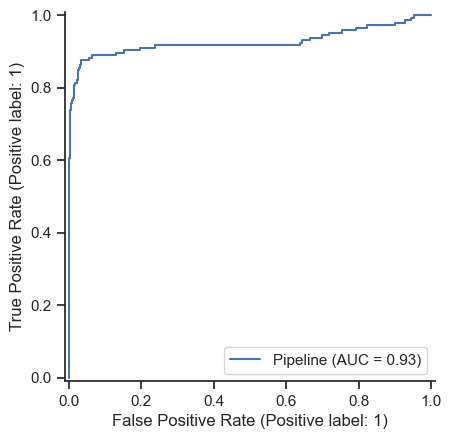

In [98]:
# ROC AUC on Test Set
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(
    estimator=best_model_pipeline,
    X=X_test,
    y=y_test
    )
plt.show()

# Confusion Matrix

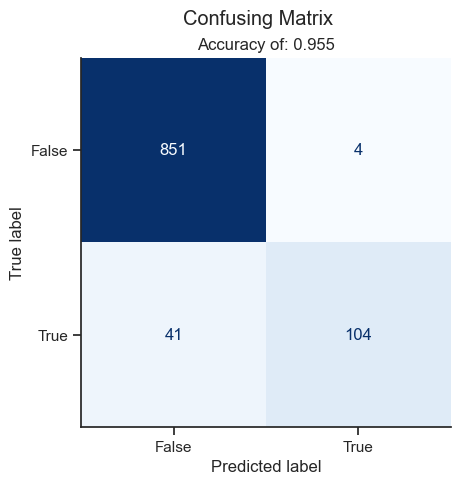

In [99]:
# Confusion on Test Set
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
ConfusionMatrixDisplay.from_estimator(
    estimator=best_model_pipeline,
    X=X_test,
    y=y_test,
    cmap='Blues',
    colorbar=False)
plt.suptitle('Confusing Matrix')
plt.title(f'Accuracy of: {accuracy_score(y_true=y_test, y_pred=best_model_pipeline.predict(X_test))}')
plt.show()

# Saving Model

In [100]:
# Save Model
from datetime import datetime
import joblib
model_name = 'XGB-C'
model_file_name = f'models/{model_name} on {datetime.now().strftime("%Y %b %d at %H.%M.%S")}.pkl'
joblib.dump(best_model_pipeline, model_file_name)

['models/XGB-C on 2026 Jul 06 at 13.50.13.pkl']